# Pandas y Valores Faltandes




## Wine Reviews dataset

Vamos a trabajar con el siguiente dataset, que corresponde a reviews de vinos:

https://www.kaggle.com/zynicide/wine-reviews/downloads/wine-reviews.zip/4

Por favor leer su descripción y, cuando tengan tiempo, mirar algunos de los "kernels" que pueden encontrar en Kaggle.

1. Abrir el dataset e imprimir sus primeras instancias.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
wine_reviews = pd.read_csv("wine_reviews.csv")
wine_reviews.head(2)

,Unnamed: 0,country,description,designation,points,price,province,region_1,region_2,taster_name,taster_twitter_handle,title,variety,winery
0,0,Italy,"Aromas include tropical fruit, broom, brimston...",Vulkà Bianco,87,NaN,Sicily & Sardinia,Etna,NaN,Kerin O’Keefe,@kerinokeefe,Nicosia 2013 Vulkà Bianco (Etna),White Blend,Nicosia
1,1,Portugal,"This is ripe and fruity, a wine that is smooth...",Avidagos,87,15.0,Douro,NaN,NaN,Roger Voss,@vossroger,Quinta dos Avidagos 2011 Avidagos Red (Douro),Portuguese Red,Quinta dos Avidagos


2. ¿Cuántas columnas (features) tiene?¿Cuáles son sus nombres?¿Y cuántas filas (instancias)? Luego, descartar la columna `'Unnamed: 0'`.

(129971, 14)
Index(['Unnamed: 0', 'country', 'description', 'designation', 'points',
       'price', 'province', 'region_1', 'region_2', 'taster_name',
       'taster_twitter_handle', 'title', 'variety', 'winery'],
      dtype='object')


3. ¿Cuántos valores faltantes hay en cada columna?

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129971 entries, 0 to 129970
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   country                129908 non-null  object 
 1   description            129971 non-null  object 
 2   designation            92506 non-null   object 
 3   points                 129971 non-null  int64  
 4   price                  120975 non-null  float64
 5   province               129908 non-null  object 
 6   region_1               108724 non-null  object 
 7   region_2               50511 non-null   object 
 8   taster_name            103727 non-null  object 
 9   taster_twitter_handle  98758 non-null   object 
 10  title                  129971 non-null  object 
 11  variety                129970 non-null  object 
 12  winery                 129971 non-null  object 
dtypes: float64(1), int64(1), object(11)
memory usage: 12.9+ MB


country                     63
description                  0
designation              37465
points                       0
price                     8996
province                    63
region_1                 21247
region_2                 79460
taster_name              26244
taster_twitter_handle    31213
title                        0
variety                      1
winery                       0
dtype: int64

4. ¿Cuál o cuáles son los vinos con más valores faltantes?

86909

country                                                              Chile
description              A chalky, dusty mouthfeel nicely balances this...
designation                                                            NaN
points                                                                  88
price                                                                 17.0
province                                                      Maipo Valley
region_1                                                               NaN
region_2                                                               NaN
taster_name                                                            NaN
taster_twitter_handle                                                  NaN
title                                          Carmen 1999  (Maipo Valley)
variety                                                                NaN
winery                                                              Carmen
Name: 86909, dtype: objec

5. Hacerse alguna pregunta acerca del dataset e intentar responderla. Por ejemplo, ¿cuáles son el peor y el mejor vino? Imprimir en pantalla sus características y su descripción. ¿Hay un solo vino que sea el mejor o el peor?

19

country                                                          Australia
description              This wine contains some material over 100 year...
designation                                                           Rare
points                                                                 100
price                                                                350.0
province                                                          Victoria
region_1                                                        Rutherglen
region_2                                                               NaN
taster_name                                                 Joe Czerwinski
taster_twitter_handle                                               @JoeCz
title                    Chambers Rosewood Vineyards NV Rare Muscat (Ru...
variety                                                             Muscat
winery                                         Chambers Rosewood Vineyards
Name: 345, dtype: object

country                                                              Chile
description              Aromas of pumpkin, squash and corn chips are s...
designation                                                   Gran Reserva
points                                                                  80
price                                                                 19.0
province                                                      Leyda Valley
region_1                                                               NaN
region_2                                                               NaN
taster_name                                              Michael Schachner
taster_twitter_handle                                          @wineschach
title                    Viña Tarapacá 2015 Gran Reserva Chardonnay (Le...
variety                                                         Chardonnay
winery                                                       Viña Tarapacá
Name: 344, dtype: object

397

## Trabajando con datos faltantes

Antes de realizar cada una de las siguientes consignas, recordá copiar el dataset en una nueva variable, así mantemos el dataset original sin modificar.

1. Descartar aquellas filas que tengan algún valor faltante. ¿Cuántas instancias quedan en el dataset?

129971

(22387, 13)

2. Descartar aquellas columnas que tengan algún valor faltante. ¿Cuántos y cuáles atributos quedaron?

(129971, 13)

(129971, 4)

Pueden observar que descartar sin ningún criterio puede hacer que perdamos muchos datos.

Tratemos de mejorar un poco los criterios con los que descartamos.

3. Descartar aquellas filas que tengan más de tres valores faltantes. ¿Cuántas instancias quedaron?

(129971, 14)

(104718, 14)

8              8
15            15
19            19
31            31
32            32
           ...  
129929    129929
129940    129940
129946    129946
129955    129955
129966    129966
Name: index, Length: 25253, dtype: int64

,index,country,description,designation,points,price,province,region_1,region_2,taster_name,taster_twitter_handle,title,variety,winery
32,32,Italy,"Part of the extended Calanìca series, this Gri...",Calanìca Grillo-Viognier,86,NaN,Sicily & Sardinia,Sicilia,NaN,NaN,NaN,Duca di Salaparuta 2011 Calanìca Grillo-Viogni...,White Blend,Duca di Salaparuta


4. Descartar aquellas columnas que tengan más del 50% de valores faltantes. ¿Cuántos y cuáles atributos quedaron? Luego, descartar las instancias que tengan algún valor faltante.

In [ ]:
# Hacer una copia del dataframe



(129971, 13)

In [ ]:
# Calcular el 50% de las filas


64985.5

(129971, 12)

(52106, 12)

## Imputación de Valores Faltantes

La columna `price` tiene alrededor de 9 mil valores faltantes, pero no queremos descartarla ni descartar instancias por el simple hecho de que no sepamos su precio. Esto se debe a que el precio tiene mucha información y, eventualmente, puede ser la columna que querramos predecir. Además, no son tantos valores faltantes si consideramos la cantidad de instancias que tiene el dataset. Entonces:


1. Calcular el valor medio, moda, mediana y la desviación estándar de la columna `price`.

35.363389129985535
20.0
25.0
41.02221766808723


3300.0

(array([6.1000e+02, 7.7280e+03, 1.6764e+04, 1.4299e+04, 1.3244e+04,
        1.1530e+04, 9.5560e+03, 7.5010e+03, 4.5710e+03, 5.4690e+03,
        4.4620e+03, 5.4670e+03, 1.1670e+03, 2.8290e+03, 2.8520e+03,
        2.0160e+03, 1.6060e+03, 3.1600e+02, 1.6190e+03, 1.0260e+03,
        8.0100e+02, 1.9900e+02, 7.6600e+02, 4.9400e+02, 7.3200e+02,
        1.9500e+02, 7.6000e+01, 2.5500e+02, 1.4900e+02, 2.8400e+02,
        2.0000e+01, 3.5700e+02, 1.6800e+02, 1.2200e+02, 1.3500e+02,
        2.3000e+01, 8.0000e+01, 2.6200e+02, 4.4000e+01, 9.0000e+00,
        7.1000e+01, 4.6000e+01, 5.3000e+01, 8.5000e+01, 9.0000e+00,
        3.6000e+01, 2.3000e+01, 3.0000e+01, 3.0000e+01, 1.3000e+01]),
 array([  4. ,   7.9,  11.8,  15.7,  19.6,  23.5,  27.4,  31.3,  35.2,
         39.1,  43. ,  46.9,  50.8,  54.7,  58.6,  62.5,  66.4,  70.3,
         74.2,  78.1,  82. ,  85.9,  89.8,  93.7,  97.6, 101.5, 105.4,
        109.3, 113.2, 117.1, 121. , 124.9, 128.8, 132.7, 136.6, 140.5,
        144.4, 148.3, 152.2, 156.1

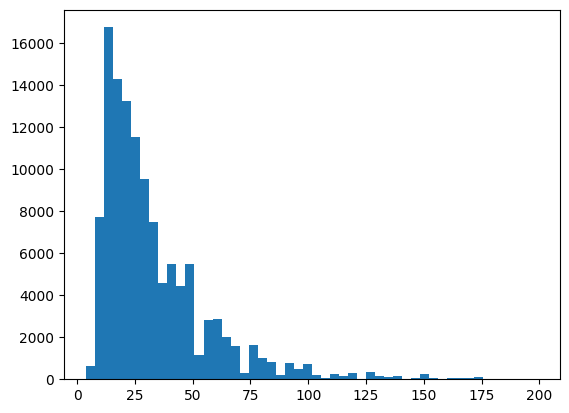

2. Imputar los valores faltantes en la columna `price` usando su valor medio.

3. ¿Cambió el valor medio de la columna?¿Y su desviación estándar?¿Y los otros estadísticos que calculamos?¿Por qué?

35.363389129985535
35.363389129985535
28.0
39.577066045021446


(array([6.1000e+02, 7.7280e+03, 1.6764e+04, 1.4299e+04, 1.3244e+04,
        1.1530e+04, 9.5560e+03, 7.5010e+03, 1.3567e+04, 5.4690e+03,
        4.4620e+03, 5.4670e+03, 1.1670e+03, 2.8290e+03, 2.8520e+03,
        2.0160e+03, 1.6060e+03, 3.1600e+02, 1.6190e+03, 1.0260e+03,
        8.0100e+02, 1.9900e+02, 7.6600e+02, 4.9400e+02, 7.3200e+02,
        1.9500e+02, 7.6000e+01, 2.5500e+02, 1.4900e+02, 2.8400e+02,
        2.0000e+01, 3.5700e+02, 1.6800e+02, 1.2200e+02, 1.3500e+02,
        2.3000e+01, 8.0000e+01, 2.6200e+02, 4.4000e+01, 9.0000e+00,
        7.1000e+01, 4.6000e+01, 5.3000e+01, 8.5000e+01, 9.0000e+00,
        3.6000e+01, 2.3000e+01, 3.0000e+01, 3.0000e+01, 1.3000e+01]),
 array([  4. ,   7.9,  11.8,  15.7,  19.6,  23.5,  27.4,  31.3,  35.2,
         39.1,  43. ,  46.9,  50.8,  54.7,  58.6,  62.5,  66.4,  70.3,
         74.2,  78.1,  82. ,  85.9,  89.8,  93.7,  97.6, 101.5, 105.4,
        109.3, 113.2, 117.1, 121. , 124.9, 128.8, 132.7, 136.6, 140.5,
        144.4, 148.3, 152.2, 156.1

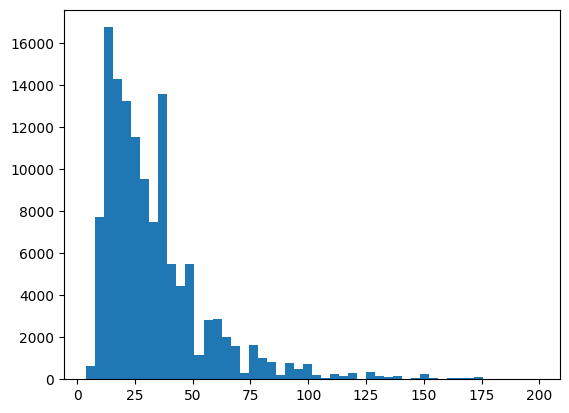

5. Trabajar con un dataset sin visualizar es muy aburrido y, diríamos, casi frustrante. Mientras tanto, intenten hacer un histograma de los puntajes asignados y, luego, de los precios.

(array([  397.,   692.,  1836.,  3025.,  6480.,  9530., 12600., 16933.,
        17207., 12226., 15410., 11359.,  9613.,  6489.,  3758.,  1535.,
          523.,   229.,    77.,    52.]),
 array([ 80.,  81.,  82.,  83.,  84.,  85.,  86.,  87.,  88.,  89.,  90.,
         91.,  92.,  93.,  94.,  95.,  96.,  97.,  98.,  99., 100.]),
 <BarContainer object of 20 artists>)

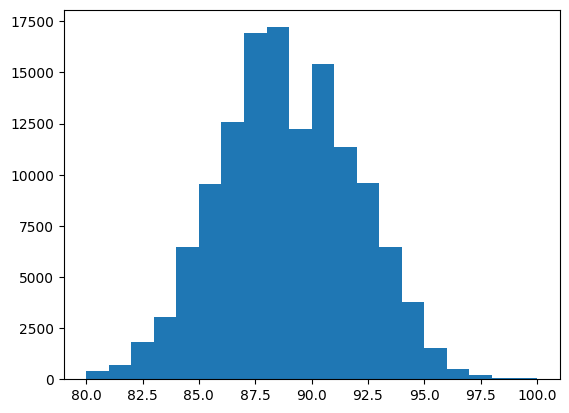

(array([  397.,   692.,  1836.,  3025.,  6480.,  9530., 12600., 16933.,
        17207., 12226., 15410., 11359.,  9613.,  6489.,  3758.,  1535.,
          523.,   229.,    77.,    52.]),
 array([ 80.,  81.,  82.,  83.,  84.,  85.,  86.,  87.,  88.,  89.,  90.,
         91.,  92.,  93.,  94.,  95.,  96.,  97.,  98.,  99., 100.]),
 <BarContainer object of 20 artists>)

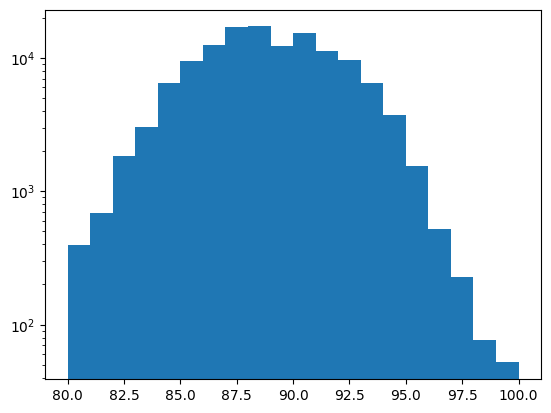